<a href="https://colab.research.google.com/github/Rageel-28/244107020136-Machine-Learning/blob/main/JS05/JS05_Tugas1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# JS05 - Klasifikasi 1
## Tugas Lab 1 - Klasifikasi Suara Male vs Female dengan kNN

**Soal:**

1. Buatlah model klasifikasi dengan kNN untuk mengklasifikasikan jenis suara `male` dan `female` pada dataset `voice.csv`.
2. Lakukan percobaan untuk mengetahui fitur-fitur yang paling optimal untuk digunakan. Fitur apa saja yang Anda gunakan untuk mendapatkan hasil terbaik?
3. Berdasarkan fitur yang telah dipilih pada soal nomor 2, berapa nilai *k* yang terbaik? Lampirkan grafik analisis dan alasan.

**Strategi yang dipakai di notebook ini:**

- Data dibagi menjadi data latih (70%) dan data uji (30%) secara **stratified**.
- Seluruh pemilihan fitur dan pemilihan *k* dilakukan dengan **5-fold cross validation pada data latih saja**. Data uji hanya dipakai untuk melaporkan hasil akhir, sehingga tidak ada kebocoran informasi (*data leakage*) dan tidak terjadi "memilih berdasarkan data uji".
- Standardisasi (`StandardScaler`) dimasukkan ke dalam `Pipeline` agar selalu di-fit hanya pada data latih di setiap lipatan (fold).

## Langkah 0 - Persiapan Dataset

In [ ]:
# Upload dataset (khusus Google Colab).
# Jika file sudah ada di folder kerja, langkah upload dilewati.
import os

if not os.path.exists('voice.csv'):
    try:
        from google.colab import files
        print('Silakan upload file voice.csv')
        files.upload()
    except ImportError:
        raise FileNotFoundError('voice.csv tidak ditemukan. Letakkan file di folder yang sama dengan notebook ini.')

print('File voice.csv tersedia:', os.path.exists('voice.csv'))

File voice.csv tersedia: True


## Langkah 1 - Load Data

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

data = pd.read_csv('voice.csv')
data.head()

,meanfreq,sd,median,Q25,Q75,IQR,skew,kurt,sp.ent,sfm,...,centroid,meanfun,minfun,maxfun,meandom,mindom,maxdom,dfrange,modindx,label
0,0.059781,0.064241,0.032027,0.015071,0.090193,0.075122,12.863462,274.402906,0.893369,0.491918,...,0.059781,0.084279,0.015702,0.275862,0.007812,0.007812,0.007812,0.000000,0.000000,male
1,0.066009,0.067310,0.040229,0.019414,0.092666,0.073252,22.423285,634.613855,0.892193,0.513724,...,0.066009,0.107937,0.015826,0.250000,0.009014,0.007812,0.054688,0.046875,0.052632,male
2,0.077316,0.083829,0.036718,0.008701,0.131908,0.123207,30.757155,1024.927705,0.846389,0.478905,...,0.077316,0.098706,0.015656,0.271186,0.007990,0.007812,0.015625,0.007812,0.046512,male
3,0.151228,0.072111,0.158011,0.096582,0.207955,0.111374,1.232831,4.177296,0.963322,0.727232,...,0.151228,0.088965,0.017798,0.250000,0.201497,0.007812,0.562500,0.554688,0.247119,male
4,0.135120,0.079146,0.124656,0.078720,0.206045,0.127325,1.101174,4.333713,0.971955,0.783568,...,0.135120,0.106398,0.016931,0.266667,0.712812,0.007812,5.484375,5.476562,0.208274,male


## Langkah 2 - Eksplorasi Data
Cek ukuran data, tipe data, nilai kosong, data duplikat, dan keseimbangan kelas.

In [ ]:
print('Ukuran data (baris, kolom):', data.shape)
print('\n=== Info Data ===')
data.info()

print('\n=== Jumlah Nilai Kosong ===')
print(data.isnull().sum().sum(), 'nilai kosong')

print('\n=== Jumlah Data Duplikat ===')
print(data.duplicated().sum(), 'baris duplikat')

print('\n=== Jumlah Data per Kelas ===')
display(data['label'].value_counts())

print('\n=== Statistik Deskriptif ===')
display(data.describe().T)

Ukuran data (baris, kolom): (3168, 21)

=== Info Data ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3168 entries, 0 to 3167
Data columns (total 21 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   meanfreq  3168 non-null   float64
 1   sd        3168 non-null   float64
 2   median    3168 non-null   float64
 3   Q25       3168 non-null   float64
 4   Q75       3168 non-null   float64
 5   IQR       3168 non-null   float64
 6   skew      3168 non-null   float64
 7   kurt      3168 non-null   float64
 8   sp.ent    3168 non-null   float64
 9   sfm       3168 non-null   float64
 10  mode      3168 non-null   float64
 11  centroid  3168 non-null   float64
 12  meanfun   3168 non-null   float64
 13  minfun    3168 non-null   float64
 14  maxfun    3168 non-null   float64
 15  meandom   3168 non-null   float64
 16  mindom    3168 non-null   float64
 17  maxdom    3168 non-null   float64
 18  dfrange   3168 non-null   float64
 19  modindx   3

,count
label,
male,1584
female,1584



=== Statistik Deskriptif ===


,count,mean,std,min,25%,50%,75%,max
meanfreq,3168.0,0.180907,0.029918,0.039363,0.163662,0.184838,0.199146,0.251124
sd,3168.0,0.057126,0.016652,0.018363,0.041954,0.059155,0.067020,0.115273
median,3168.0,0.185621,0.036360,0.010975,0.169593,0.190032,0.210618,0.261224
Q25,3168.0,0.140456,0.048680,0.000229,0.111087,0.140286,0.175939,0.247347
Q75,3168.0,0.224765,0.023639,0.042946,0.208747,0.225684,0.243660,0.273469
IQR,3168.0,0.084309,0.042783,0.014558,0.042560,0.094280,0.114175,0.252225
skew,3168.0,3.140168,4.240529,0.141735,1.649569,2.197101,2.931694,34.725453
kurt,3168.0,36.568461,134.928661,2.068455,5.669547,8.318463,13.648905,1309.612887
sp.ent,3168.0,0.895127,0.044980,0.738651,0.861811,0.901767,0.928713,0.981997
sfm,3168.0,0.408216,0.177521,0.036876,0.258041,0.396335,0.533676,0.842936


## Langkah 3 - Visualisasi Data
Boxplot setiap fitur terhadap label untuk melihat fitur mana yang terlihat membedakan `male` dan `female`, serta heatmap korelasi antar fitur.

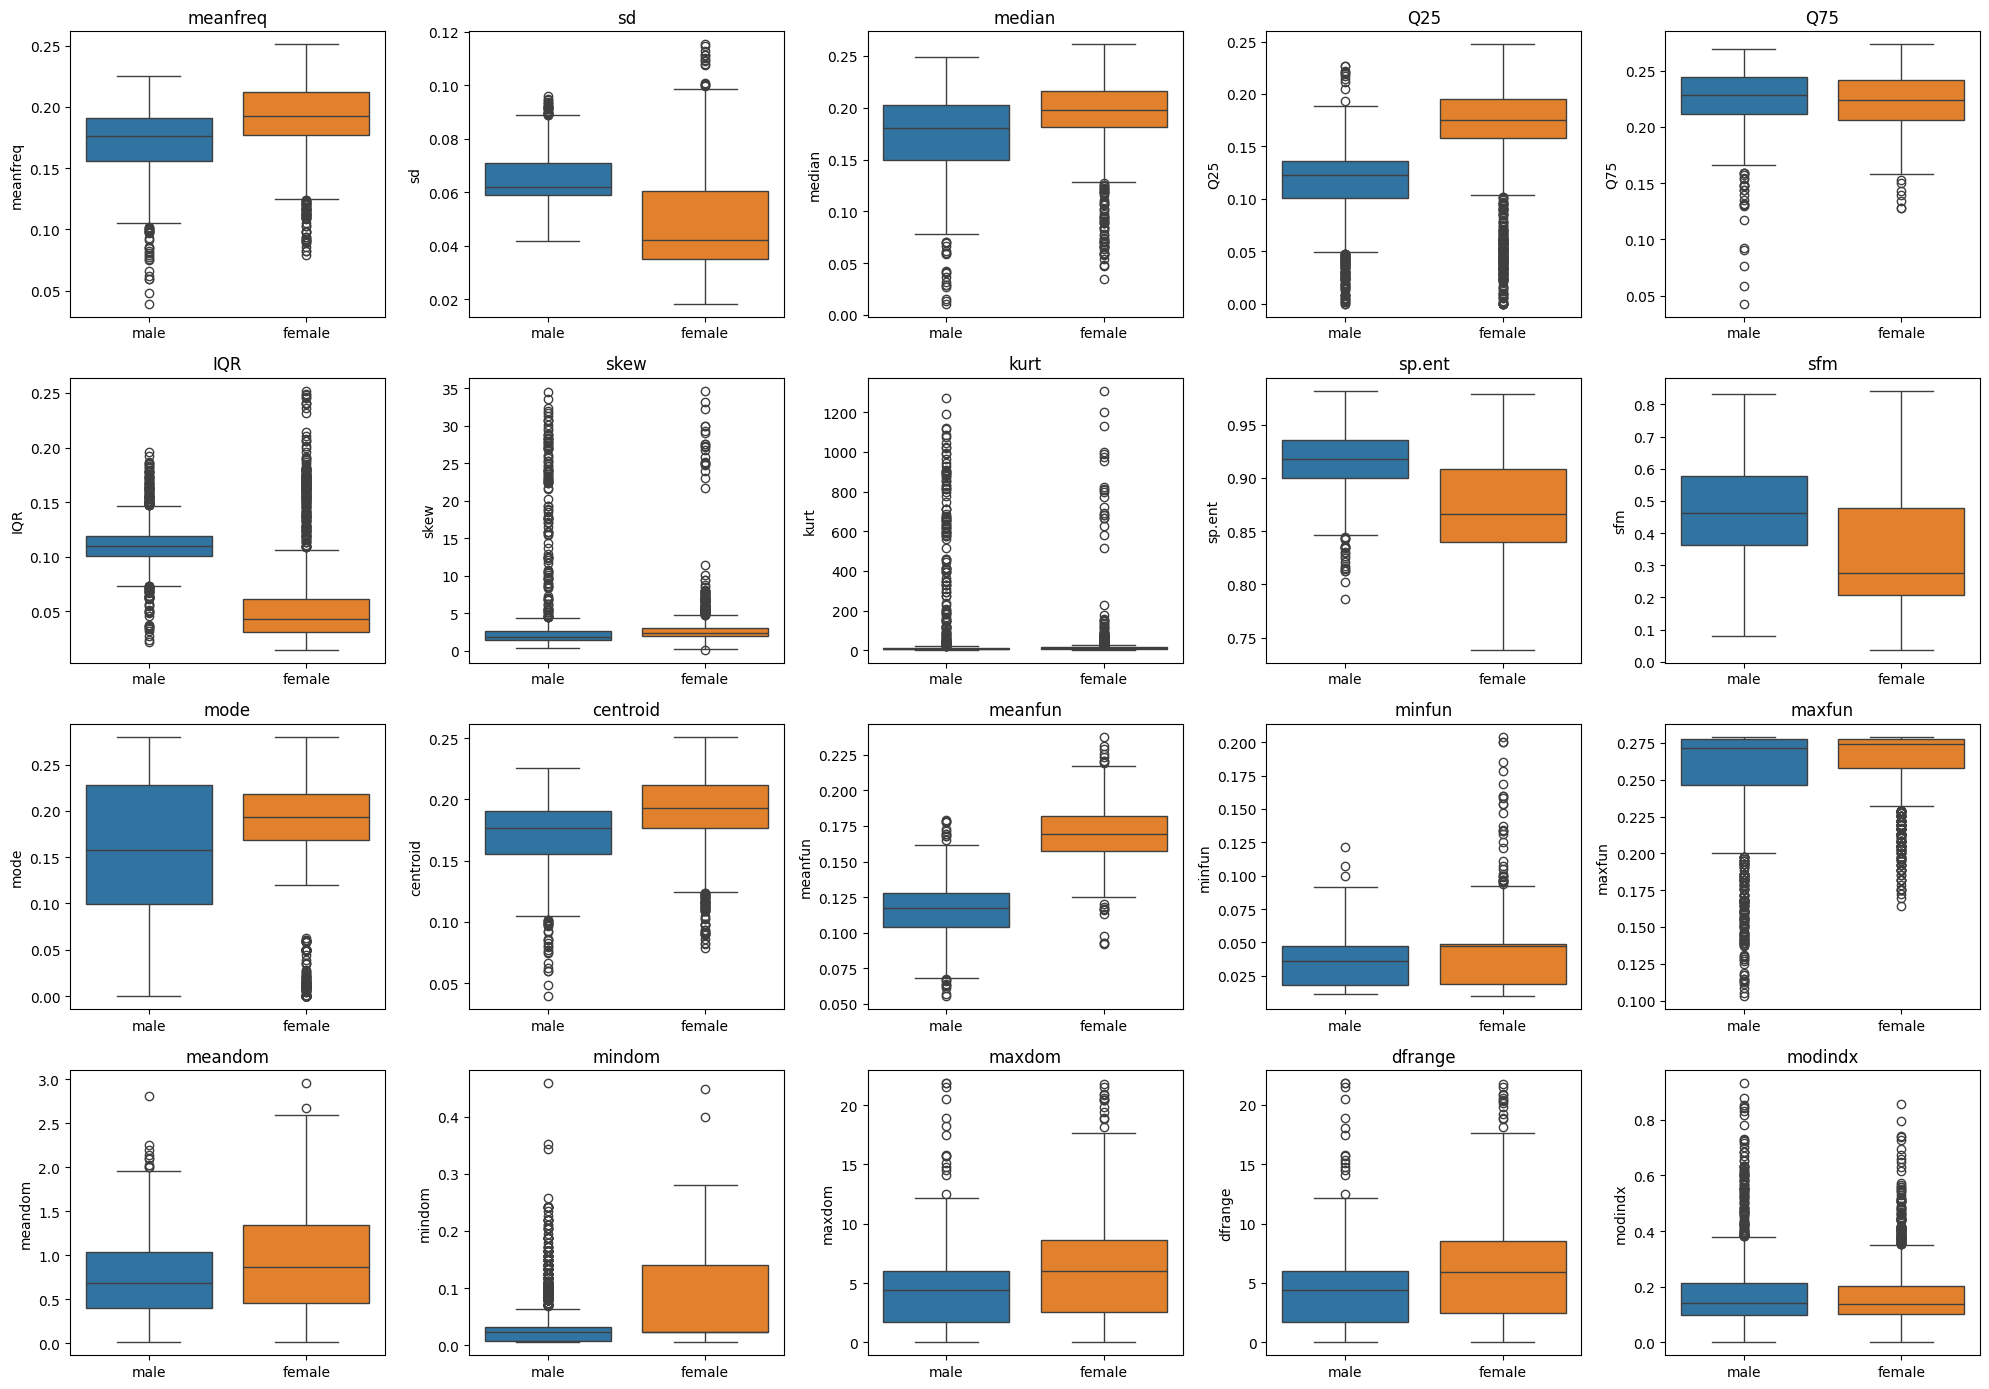

In [ ]:
fitur_cols = [c for c in data.columns if c != 'label']

fig, axes = plt.subplots(4, 5, figsize=(20, 14))
for ax, col in zip(axes.ravel(), fitur_cols):
    sns.boxplot(data=data, x='label', y=col, hue='label', ax=ax, legend=False)
    ax.set_title(col)
    ax.set_xlabel('')
plt.tight_layout()
plt.show()

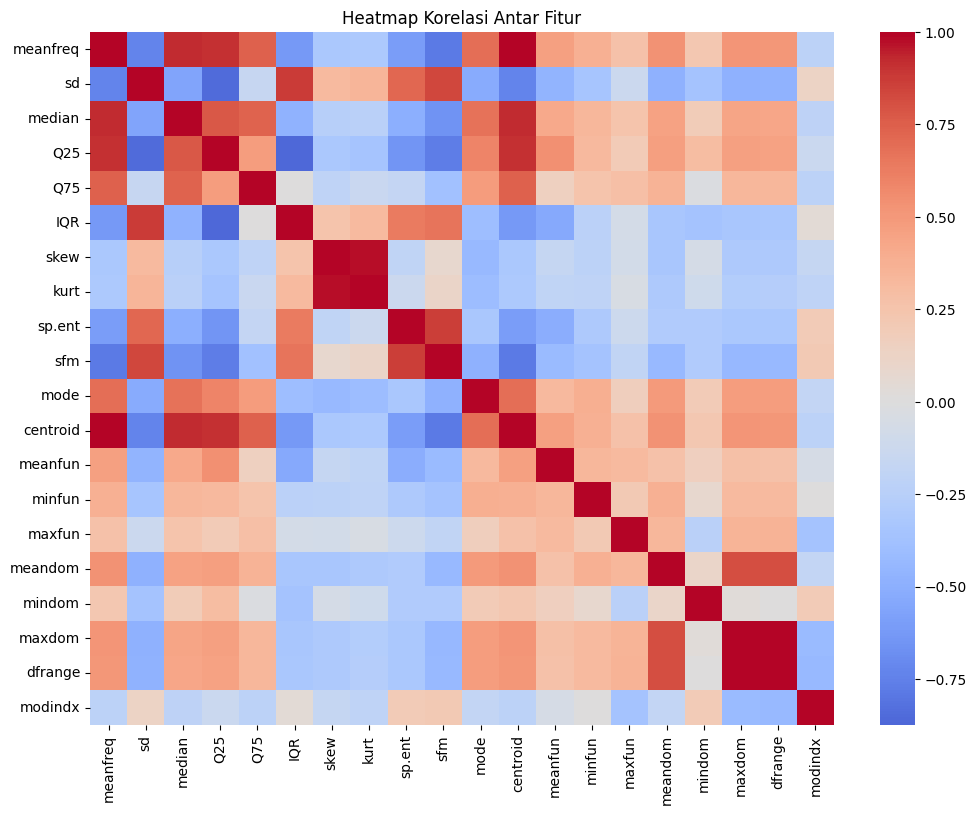

In [ ]:
plt.figure(figsize=(12, 9))
sns.heatmap(data[fitur_cols].corr(), cmap='coolwarm', center=0, annot=False)
plt.title('Heatmap Korelasi Antar Fitur')
plt.show()

## Langkah 4 - Preprocessing
Memisahkan fitur (`X`) dan label (`y`), kemudian split data latih/uji 70:30 secara stratified (`stratify=y`) agar proporsi `male` dan `female` sama di kedua bagian.

In [ ]:
from sklearn.model_selection import train_test_split, StratifiedKFold

X = data.drop(columns='label')
y = data['label']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

print('Dimensi X_train:', X_train.shape, '| X_test:', X_test.shape)
print('\nProporsi label data latih:\n', y_train.value_counts(normalize=True))
print('\nProporsi label data uji:\n', y_test.value_counts(normalize=True))

# Skema cross validation yang dipakai di seluruh percobaan
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

Dimensi X_train: (2217, 20) | X_test: (951, 20)

Proporsi label data latih:
 label
male      0.500226
female    0.499774
Name: proportion, dtype: float64

Proporsi label data uji:
 label
female    0.500526
male      0.499474
Name: proportion, dtype: float64


---
# Soal 1 - Model kNN dengan Seluruh Fitur (Baseline)
Model awal: `StandardScaler` + `KNeighborsClassifier(n_neighbors=5)` menggunakan **semua 20 fitur**.

Akurasi data latih : 0.9806044203879116
Akurasi data uji   : 0.9737118822292324

Confusion Matrix:
 [[461  15]
 [ 10 465]]

Laporan Klasifikasi:
               precision    recall  f1-score   support

      female       0.98      0.97      0.97       476
        male       0.97      0.98      0.97       475

    accuracy                           0.97       951
   macro avg       0.97      0.97      0.97       951
weighted avg       0.97      0.97      0.97       951



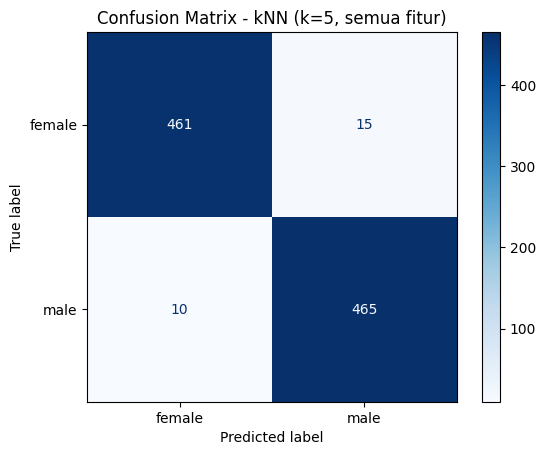

In [ ]:
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, ConfusionMatrixDisplay

baseline = make_pipeline(StandardScaler(), KNeighborsClassifier(n_neighbors=5))
baseline.fit(X_train, y_train)

y_pred = baseline.predict(X_test)
print('Akurasi data latih :', accuracy_score(y_train, baseline.predict(X_train)))
print('Akurasi data uji   :', accuracy_score(y_test, y_pred))
print('\nConfusion Matrix:\n', confusion_matrix(y_test, y_pred))
print('\nLaporan Klasifikasi:\n', classification_report(y_test, y_pred))

ConfusionMatrixDisplay.from_predictions(y_test, y_pred, cmap='Blues')
plt.title('Confusion Matrix - kNN (k=5, semua fitur)')
plt.show()

---
# Soal 2 - Mencari Fitur yang Paling Optimal
Tiga percobaan dilakukan, semuanya dievaluasi dengan 5-fold cross validation pada data latih (k tetap = 5 selama pemilihan fitur):

- **Percobaan A** - akurasi kNN dengan **satu fitur saja** (untuk melihat kekuatan tiap fitur).
- **Percobaan B** - **filter method**: `SelectKBest` dengan skor ANOVA F (`f_classif`), mencoba 1 sampai 20 fitur teratas.
- **Percobaan C** - **wrapper method**: *forward selection* dengan kNN, menambahkan satu fitur terbaik pada setiap langkah.

Setelah itu semua kandidat himpunan fitur dibandingkan.

### Percobaan A - Akurasi per Fitur Tunggal

,Akurasi CV (1 fitur)
meanfun,0.944075
IQR,0.896698
Q25,0.874593
sd,0.787089
sp.ent,0.707236
sfm,0.671181
mode,0.668464
skew,0.620650
maxdom,0.620209
meanfreq,0.611640


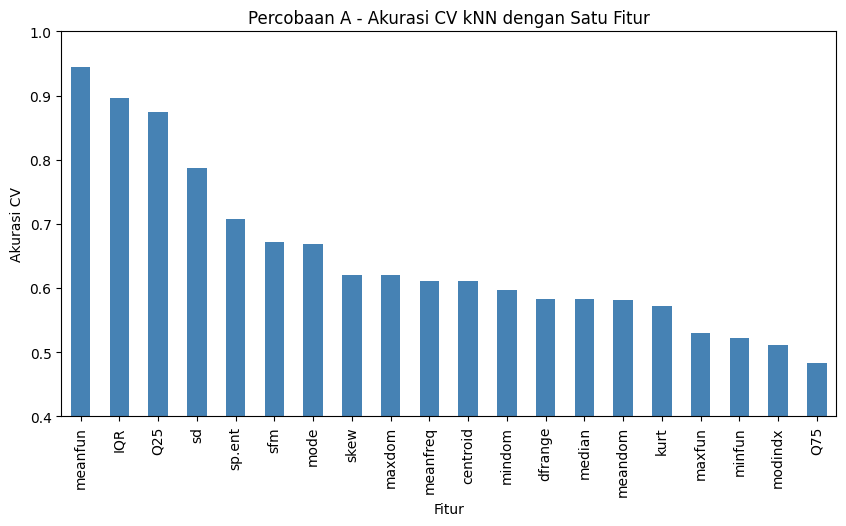

In [ ]:
from sklearn.model_selection import cross_val_score

hasil_tunggal = {}
for col in X_train.columns:
    model = make_pipeline(StandardScaler(), KNeighborsClassifier(n_neighbors=5))
    hasil_tunggal[col] = cross_val_score(model, X_train[[col]], y_train, cv=skf, scoring='accuracy').mean()

hasil_tunggal = pd.Series(hasil_tunggal).sort_values(ascending=False)
display(hasil_tunggal.to_frame('Akurasi CV (1 fitur)'))

plt.figure(figsize=(10, 5))
hasil_tunggal.plot(kind='bar', color='steelblue')
plt.title('Percobaan A - Akurasi CV kNN dengan Satu Fitur')
plt.ylabel('Akurasi CV')
plt.xlabel('Fitur')
plt.ylim(0.4, 1.0)
plt.show()

### Percobaan B - Filter Method (`SelectKBest` + ANOVA F)
Untuk setiap jumlah fitur `n = 1..20`, pipeline (`StandardScaler` -> `SelectKBest` -> `kNN`) dievaluasi dengan cross validation. Seleksi fitur berada **di dalam** pipeline sehingga dilakukan ulang pada data latih tiap fold.

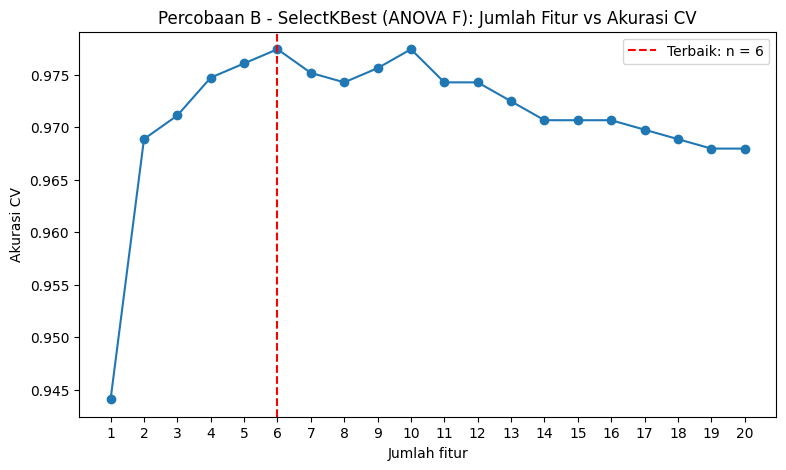

Jumlah fitur terbaik (SelectKBest): 6  | Akurasi CV = 0.9774
Fitur terpilih: ['sd', 'Q25', 'IQR', 'sp.ent', 'sfm', 'meanfun']

Skor ANOVA F per fitur (urut):


,Skor F
meanfun,4943.437345
IQR,1378.911196
Q25,777.728663
sp.ent,688.925702
sd,669.471838
sfm,336.615777
centroid,280.468247
meanfreq,280.468247
median,183.661726
mindom,86.605771


In [ ]:
from sklearn.feature_selection import SelectKBest, f_classif

n_total = X_train.shape[1]
cv_kbest = []
for n in range(1, n_total + 1):
    model = make_pipeline(StandardScaler(), SelectKBest(f_classif, k=n), KNeighborsClassifier(n_neighbors=5))
    cv_kbest.append(cross_val_score(model, X_train, y_train, cv=skf, scoring='accuracy').mean())

cv_kbest = pd.Series(cv_kbest, index=range(1, n_total + 1))
n_best_kbest = int(cv_kbest.idxmax())

plt.figure(figsize=(9, 5))
plt.plot(cv_kbest.index, cv_kbest.values, marker='o')
plt.axvline(n_best_kbest, color='red', linestyle='--', label=f'Terbaik: n = {n_best_kbest}')
plt.title('Percobaan B - SelectKBest (ANOVA F): Jumlah Fitur vs Akurasi CV')
plt.xlabel('Jumlah fitur')
plt.ylabel('Akurasi CV')
plt.xticks(range(1, n_total + 1))
plt.legend()
plt.show()

# Fitur yang terpilih pada n terbaik (selector di-fit pada seluruh data latih)
selector = SelectKBest(f_classif, k=n_best_kbest).fit(X_train, y_train)
fitur_kbest = list(X_train.columns[selector.get_support()])
skor_f = pd.Series(selector.scores_, index=X_train.columns).sort_values(ascending=False)

print(f'Jumlah fitur terbaik (SelectKBest): {n_best_kbest}  | Akurasi CV = {cv_kbest.max():.4f}')
print('Fitur terpilih:', fitur_kbest)
print('\nSkor ANOVA F per fitur (urut):')
display(skor_f.to_frame('Skor F'))

### Percobaan C - Wrapper Method: Forward Selection
Dimulai dari himpunan fitur kosong. Pada setiap langkah, dicoba menambahkan setiap fitur yang tersisa satu per satu, dan fitur yang memberi akurasi CV tertinggi dipilih. Proses diulang sampai seluruh fitur terpakai, sehingga terlihat kurva akurasi terhadap jumlah fitur.

,Langkah,Fitur ditambahkan,Akurasi CV
0,1,meanfun,0.944075
1,2,IQR,0.968879
2,3,mode,0.975195
3,4,sfm,0.979254
4,5,sp.ent,0.979705
5,6,maxdom,0.979253
6,7,minfun,0.980605
7,8,skew,0.981055
8,9,dfrange,0.980606
9,10,kurt,0.980155


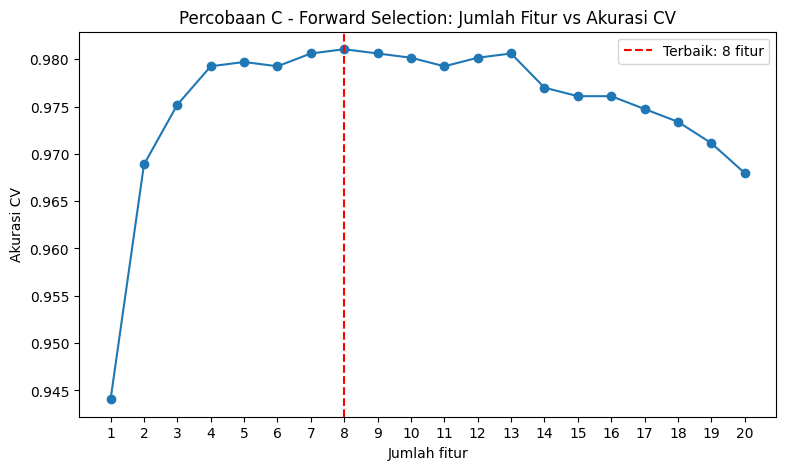

Jumlah fitur terbaik (Forward Selection): 8  | Akurasi CV = 0.9811
Fitur terpilih: ['meanfun', 'IQR', 'mode', 'sfm', 'sp.ent', 'maxdom', 'minfun', 'skew']


In [ ]:
terpilih, tersisa = [], list(X_train.columns)
riwayat = []

while tersisa:
    fitur_terbaik, skor_terbaik = None, -1
    for f in tersisa:
        model = make_pipeline(StandardScaler(), KNeighborsClassifier(n_neighbors=5))
        skor = cross_val_score(model, X_train[terpilih + [f]], y_train, cv=skf, scoring='accuracy').mean()
        if skor > skor_terbaik:
            fitur_terbaik, skor_terbaik = f, skor
    terpilih.append(fitur_terbaik)
    tersisa.remove(fitur_terbaik)
    riwayat.append({'Langkah': len(terpilih), 'Fitur ditambahkan': fitur_terbaik, 'Akurasi CV': skor_terbaik})

riwayat = pd.DataFrame(riwayat)
display(riwayat)

n_best_fwd = int(riwayat.loc[riwayat['Akurasi CV'].idxmax(), 'Langkah'])
fitur_fwd = terpilih[:n_best_fwd]

plt.figure(figsize=(9, 5))
plt.plot(riwayat['Langkah'], riwayat['Akurasi CV'], marker='o')
plt.axvline(n_best_fwd, color='red', linestyle='--', label=f'Terbaik: {n_best_fwd} fitur')
plt.title('Percobaan C - Forward Selection: Jumlah Fitur vs Akurasi CV')
plt.xlabel('Jumlah fitur')
plt.ylabel('Akurasi CV')
plt.xticks(range(1, n_total + 1))
plt.legend()
plt.show()

print(f'Jumlah fitur terbaik (Forward Selection): {n_best_fwd}  | Akurasi CV = {riwayat["Akurasi CV"].max():.4f}')
print('Fitur terpilih:', fitur_fwd)

### Perbandingan Himpunan Fitur
Setiap kandidat himpunan fitur dibandingkan dengan akurasi CV (data latih) dan akurasi data uji. **Pemilihan himpunan terbaik berdasarkan akurasi CV** (bukan data uji); jika sama, dipilih yang jumlah fiturnya lebih sedikit.

> Catatan: akurasi CV forward selection cenderung sedikit optimis karena fitur dipilih menggunakan fold yang sama. Akurasi data uji adalah tolok ukur yang tidak bias.

In [ ]:
kandidat = {
    'Semua fitur': list(X_train.columns),
    'SelectKBest (ANOVA F)': fitur_kbest,
    'Forward Selection': fitur_fwd,
}

baris = []
for nama, fitur in kandidat.items():
    model = make_pipeline(StandardScaler(), KNeighborsClassifier(n_neighbors=5))
    cv_acc = cross_val_score(model, X_train[fitur], y_train, cv=skf, scoring='accuracy').mean()
    model.fit(X_train[fitur], y_train)
    baris.append({
        'Metode': nama,
        'Jumlah fitur': len(fitur),
        'Akurasi CV (train)': cv_acc,
        'Akurasi Test': model.score(X_test[fitur], y_test),
    })

perbandingan = pd.DataFrame(baris)
display(perbandingan)

# Pilih berdasarkan akurasi CV tertinggi; jika sama, jumlah fitur paling sedikit
terbaik = perbandingan.sort_values(['Akurasi CV (train)', 'Jumlah fitur'], ascending=[False, True]).iloc[0]
fitur_final = kandidat[terbaik['Metode']]

print('\n=== JAWABAN SOAL 2 ===')
print(f"Himpunan fitur terbaik : {terbaik['Metode']} ({int(terbaik['Jumlah fitur'])} fitur)")
print('Fitur yang digunakan   :', fitur_final)
print(f"Akurasi CV             : {terbaik['Akurasi CV (train)']:.4f}")
print(f"Akurasi data uji       : {terbaik['Akurasi Test']:.4f}")

,Metode,Jumlah fitur,Akurasi CV (train),Akurasi Test
0,Semua fitur,20,0.967972,0.973712
1,SelectKBest (ANOVA F),6,0.977448,0.983176
2,Forward Selection,8,0.981055,0.981073



=== JAWABAN SOAL 2 ===
Himpunan fitur terbaik : Forward Selection (8 fitur)
Fitur yang digunakan   : ['meanfun', 'IQR', 'mode', 'sfm', 'sp.ent', 'maxdom', 'minfun', 'skew']
Akurasi CV             : 0.9811
Akurasi data uji       : 0.9811


---
# Soal 3 - Nilai *k* Terbaik untuk Fitur Terpilih
Menggunakan himpunan fitur dari Soal 2 (`fitur_final`), nilai *k* dicoba dari 1 sampai 30. Untuk setiap *k* dicatat:

- akurasi data latih,
- akurasi cross validation (rata-rata dan simpangan baku),
- akurasi data uji.

*k* terbaik dipilih berdasarkan **akurasi CV tertinggi** (jika sama, dipilih *k* yang lebih kecil).

In [ ]:
k_range = range(1, 31)
baris = []
for k in k_range:
    model = make_pipeline(StandardScaler(), KNeighborsClassifier(n_neighbors=k))
    skor_cv = cross_val_score(model, X_train[fitur_final], y_train, cv=skf, scoring='accuracy')
    model.fit(X_train[fitur_final], y_train)
    baris.append({
        'k': k,
        'Akurasi Train': model.score(X_train[fitur_final], y_train),
        'Akurasi CV (mean)': skor_cv.mean(),
        'Akurasi CV (std)': skor_cv.std(),
        'Akurasi Test': model.score(X_test[fitur_final], y_test),
    })

hasil_k = pd.DataFrame(baris).set_index('k')
display(hasil_k)

k_terbaik = int(hasil_k['Akurasi CV (mean)'].idxmax())
print(f"k terbaik = {k_terbaik} (Akurasi CV = {hasil_k.loc[k_terbaik, 'Akurasi CV (mean)']:.4f}, "
      f"Akurasi Test = {hasil_k.loc[k_terbaik, 'Akurasi Test']:.4f})")

,Akurasi Train,Akurasi CV (mean),Akurasi CV (std),Akurasi Test
k,,,,
1,1.000000,0.978350,0.001089,0.982124
2,0.990528,0.978802,0.002279,0.982124
3,0.990528,0.979704,0.003764,0.981073
4,0.987821,0.982862,0.003050,0.984227
5,0.986468,0.981055,0.003938,0.981073
6,0.986468,0.978351,0.004176,0.980021
7,0.986468,0.977000,0.005008,0.980021
8,0.985115,0.975194,0.004269,0.981073
9,0.981507,0.974744,0.004580,0.976866


k terbaik = 4 (Akurasi CV = 0.9829, Akurasi Test = 0.9842)


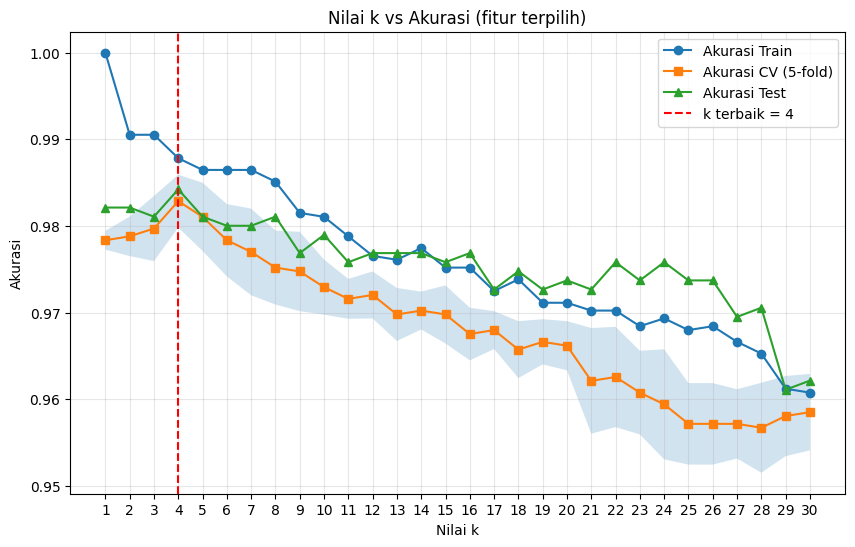

In [ ]:
plt.figure(figsize=(10, 6))
plt.plot(hasil_k.index, hasil_k['Akurasi Train'], marker='o', label='Akurasi Train')
plt.plot(hasil_k.index, hasil_k['Akurasi CV (mean)'], marker='s', label='Akurasi CV (5-fold)')
plt.fill_between(hasil_k.index,
                 hasil_k['Akurasi CV (mean)'] - hasil_k['Akurasi CV (std)'],
                 hasil_k['Akurasi CV (mean)'] + hasil_k['Akurasi CV (std)'], alpha=0.2)
plt.plot(hasil_k.index, hasil_k['Akurasi Test'], marker='^', label='Akurasi Test')
plt.axvline(k_terbaik, color='red', linestyle='--', label=f'k terbaik = {k_terbaik}')
plt.title('Nilai k vs Akurasi (fitur terpilih)')
plt.xlabel('Nilai k')
plt.ylabel('Akurasi')
plt.xticks(range(1, 31, 1))
plt.legend()
plt.grid(alpha=0.3)
plt.show()

## Evaluasi Model Akhir
Model akhir: `StandardScaler` + kNN dengan *k* terbaik dan fitur terpilih, dievaluasi pada data uji.

Fitur  : ['meanfun', 'IQR', 'mode', 'sfm', 'sp.ent', 'maxdom', 'minfun', 'skew']
k      : 4
Akurasi data uji: 0.9842271293375394

Confusion Matrix:
 [[470   6]
 [  9 466]]

Laporan Klasifikasi:
               precision    recall  f1-score   support

      female       0.98      0.99      0.98       476
        male       0.99      0.98      0.98       475

    accuracy                           0.98       951
   macro avg       0.98      0.98      0.98       951
weighted avg       0.98      0.98      0.98       951



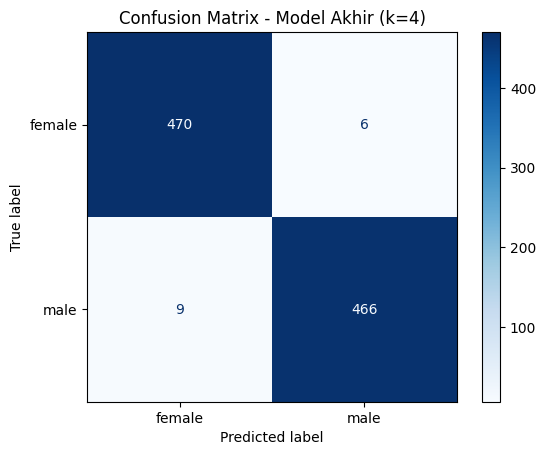


=== Perbandingan dengan Baseline ===


,Model,Akurasi Test
0,"Baseline (20 fitur, k=5)",0.973712
1,"Final (8 fitur, k=4)",0.984227


In [ ]:
model_final = make_pipeline(StandardScaler(), KNeighborsClassifier(n_neighbors=k_terbaik))
model_final.fit(X_train[fitur_final], y_train)
y_pred_final = model_final.predict(X_test[fitur_final])

print('Fitur  :', fitur_final)
print('k      :', k_terbaik)
print('Akurasi data uji:', accuracy_score(y_test, y_pred_final))
print('\nConfusion Matrix:\n', confusion_matrix(y_test, y_pred_final))
print('\nLaporan Klasifikasi:\n', classification_report(y_test, y_pred_final))

ConfusionMatrixDisplay.from_predictions(y_test, y_pred_final, cmap='Blues')
plt.title(f'Confusion Matrix - Model Akhir (k={k_terbaik})')
plt.show()

# Perbandingan dengan baseline Soal 1
print('\n=== Perbandingan dengan Baseline ===')
display(pd.DataFrame({
    'Model': ['Baseline (20 fitur, k=5)', f'Final ({len(fitur_final)} fitur, k={k_terbaik})'],
    'Akurasi Test': [accuracy_score(y_test, baseline.predict(X_test)), accuracy_score(y_test, y_pred_final)],
}))

---
# Kesimpulan dan Jawaban Tugas Lab 1

### Soal 1 - Model kNN
Model kNN dengan seluruh 20 fitur (setelah standardisasi, `k = 5`) memperoleh **akurasi uji 0.9737** (confusion matrix: 461 + 465 benar, 15 + 10 salah dari 951 sampel).

### Soal 2 - Fitur paling optimal
| Himpunan fitur | Jumlah | Akurasi CV (train) | Akurasi Test |
|---|---|---|---|
| Semua fitur | 20 | 0.9680 | 0.9737 |
| SelectKBest (ANOVA F) | 6 | 0.9774 | 0.9832 |
| **Forward Selection** | **8** | **0.9811** | **0.9811** |

**Fitur terbaik (dipilih berdasarkan akurasi CV tertinggi):** `meanfun`, `IQR`, `mode`, `sfm`, `sp.ent`, `maxdom`, `minfun`, `skew`.

Hal-hal yang mendukung jawaban ini:

- **`meanfun`** (rata-rata frekuensi fundamental) adalah fitur paling kuat: sendirian saja sudah memberi akurasi CV 0.944, dan memiliki skor ANOVA F tertinggi (4943). Hal ini sejalan dengan boxplot, di mana sebaran `meanfun` antara `male` dan `female` hampir tidak tumpang tindih. Fitur kuat berikutnya adalah `IQR` dan `Q25`.
- Memakai **semua fitur justru kurang baik** (CV 0.9680) dibanding subset fitur (CV 0.977 sampai 0.981). Pada kNN setiap fitur ikut dihitung dalam jarak, sehingga fitur yang kurang informatif atau redundan menambah *noise*. Pada dataset ini terdapat fitur redundan: `meanfreq` identik dengan `centroid`, dan `dfrange` sama dengan `maxdom - mindom`.
- Akurasi CV Forward Selection pada kurva naik cepat sampai sekitar 4 sampai 8 fitur, lalu mendatar dan menurun ketika fitur yang kurang berguna ditambahkan.
- **Catatan kehati-hatian:** selisih akurasi uji antara SelectKBest (0.9832) dan Forward Selection (0.9811) hanya sekitar 2 sampel dari 951, jadi keduanya setara secara praktis. Forward Selection dipilih karena aturan pemilihan (CV tertinggi) ditetapkan sebelum melihat data uji. Selain itu, akurasi CV forward selection cenderung sedikit optimis karena fitur dipilih dengan fold yang sama.

### Soal 3 - Nilai *k* terbaik
Menggunakan 8 fitur terpilih, **k terbaik = 4** (akurasi CV 0.9829, akurasi uji 0.9842).

Alasan berdasarkan grafik "Nilai k vs Akurasi":

- **k sangat kecil (k = 1)**: akurasi latih 1.0 tetapi akurasi CV hanya 0.9784, ada kecenderungan *overfitting* (model terlalu mengikuti noise).
- **k = 3 sampai 5**: akurasi CV tertinggi (0.9797, **0.9829**, 0.9811) dan akurasi uji juga tertinggi (sekitar 0.981 sampai 0.984).
- **k besar (k > 8)**: akurasi latih dan CV cenderung turun terus (CV sekitar 0.9585 pada k = 30), sedangkan akurasi uji ikut menurun walau berfluktuasi karena batas keputusan menjadi terlalu halus (*underfitting*).
- Perbedaan antara k = 3, 4, dan 5 masih berada dalam kisaran satu simpangan baku CV (sekitar 0.003 sampai 0.004), sehingga ketiganya hampir setara. Karena ini klasifikasi dua kelas, **nilai k ganjil (3 atau 5) lebih aman** untuk menghindari hasil voting seri; `k = 4` tetap dipilih sebagai jawaban karena memiliki akurasi CV tertinggi.

**Model akhir** (8 fitur, `k = 4`): akurasi uji **0.9842**, naik dari baseline 0.9737 (kesalahan klasifikasi turun dari 25 menjadi 15 sampel).